# Análise exploratória financeira

O notebook descreve volume e receita trimestrais de diesel e gasolina da Petrobras na tabela `pbr_quarterly_diesel_gasoline`.

Também traça lucro bruto e margem bruta do segmento **RT&M** (nota 8 do ITR). A Petrobras não publica margem bruta por produto.


In [9]:
import sys
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8')

cwd = Path.cwd().resolve()
if (cwd / 'src').is_dir() and (cwd / 'data').is_dir():
    project_root = cwd
elif (cwd.parent / 'src').is_dir() and (cwd.parent / 'data').is_dir():
    project_root = cwd.parent
else:
    raise FileNotFoundError(
        'Could not locate proj_IV root (expected src/ and data/). '
        'Open notebooks from proj_IV/ or proj_IV/notebooks/.'
    )

sys.path.insert(0, str(project_root / 'src'))

from db_access import read_engine, resolve_database_url, table_exists

ENGINE = read_engine(project_root)
DATABASE_URL = resolve_database_url(project_root)
DATABASE_URL

'sqlite:///D:\\Users\\Ricardo\\Documents\\opencode\\proj_IV\\data\\gas_flare.sqlite'

In [10]:
TABLE = 'pbr_quarterly_diesel_gasoline'

query = f'''
SELECT
    quarter,
    year,
    quarter_num,
    diesel_mbpd,
    gasoline_mbpd,
    diesel_revenue_rsmn,
    gasoline_revenue_rsmn,
    total_revenue_rsmn,
    rtm_sales_revenue_rsmn,
    rtm_gross_profit_rsmn,
    rtm_gross_margin_pct,
    source_prod_doc,
    source_fin_doc,
    extraction_note,
    updated_at
FROM {TABLE}
ORDER BY year, quarter_num
'''

if not table_exists(ENGINE, TABLE):
    raise ValueError(f'Missing table: {TABLE} in data/gas_flare.sqlite')
df = pd.read_sql_query(query, ENGINE)
ppi_anchor = pd.to_datetime(
    pd.read_sql_query('SELECT MIN(report_date) AS d FROM ppi_daily', ENGINE).iloc[0, 0]
)

df['quarter_period'] = pd.PeriodIndex([f"{int(y)}Q{int(q)}" for y, q in zip(df['year'], df['quarter_num'])], freq='Q')
df['quarter_end'] = df['quarter_period'].dt.end_time.dt.normalize()
df = df[df['quarter_end'] >= ppi_anchor].copy()
print(f'PPI anchor: {ppi_anchor.date()} — kept {len(df)} quarters')

numeric_cols = [
    'diesel_mbpd',
    'gasoline_mbpd',
    'diesel_revenue_rsmn',
    'gasoline_revenue_rsmn',
    'total_revenue_rsmn',
    'rtm_sales_revenue_rsmn',
    'rtm_gross_profit_rsmn',
    'rtm_gross_margin_pct',
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.head()


PPI anchor: 2022-01-05 — kept 18 quarters


,quarter,year,quarter_num,diesel_mbpd,gasoline_mbpd,diesel_revenue_rsmn,gasoline_revenue_rsmn,total_revenue_rsmn,rtm_sales_revenue_rsmn,rtm_gross_profit_rsmn,rtm_gross_margin_pct,source_prod_doc,source_fin_doc,extraction_note,updated_at,quarter_period,quarter_end
64,1Q22,2022,1,716.0,402.0,38875.0,19404.0,58279.0,128476.0,16311.0,12.695756,Production & Sales Report 1Q22,ITR,,2026-06-25T15:34:55.134622+00:00,2022Q1,2022-03-31
65,2Q22,2022,2,750.0,375.0,52603.0,21187.0,73790.0,157429.0,25532.0,16.218105,Production & Sales Report 2Q22,FS Reais Ing,,2026-06-25T15:34:55.134622+00:00,2022Q2,2022-06-30
66,3Q22,2022,3,784.0,405.0,61343.0,21575.0,82918.0,154035.0,14428.0,9.366702,Production & Sales Report 3Q22,FS Reais Ing,,2026-06-25T15:34:55.134622+00:00,2022Q3,2022-09-30
67,4Q22,2022,4,769.0,447.0,54139.0,-7404.0,46735.0,144757.0,17493.0,12.084390,Production & Sales Report 4Q22,FS Reais Ing,Q4 revenue derived as FY minus Jan-Sep; Q4 RT&...,2026-06-25T15:34:55.134622+00:00,2022Q4,2022-12-31
68,1Q23,2023,1,714.0,414.0,43150.0,19189.0,62339.0,129052.0,15449.0,11.971143,Production & Sales Report 1Q23,DFP Reais Eng,,2026-06-25T15:34:55.134622+00:00,2023Q1,2023-03-31


In [11]:
print(f'Rows: {len(df):,}')
print(f"Quarter range: {df['quarter'].iloc[0]} to {df['quarter'].iloc[-1]}")
print(f"Last update timestamp: {df['updated_at'].max()}")

null_summary = df[numeric_cols].isna().sum().rename('null_count').to_frame()
display(null_summary)

display(df[['quarter', 'diesel_mbpd', 'gasoline_mbpd', 'diesel_revenue_rsmn', 'gasoline_revenue_rsmn', 'total_revenue_rsmn', 'extraction_note']])

Rows: 18
Quarter range: 1Q22 to 2Q26
Last update timestamp: 2026-08-15T12:29:12.221727+00:00


,null_count
diesel_mbpd,1
gasoline_mbpd,1
diesel_revenue_rsmn,2
gasoline_revenue_rsmn,2
total_revenue_rsmn,2
rtm_sales_revenue_rsmn,2
rtm_gross_profit_rsmn,2
rtm_gross_margin_pct,2


,quarter,diesel_mbpd,gasoline_mbpd,diesel_revenue_rsmn,gasoline_revenue_rsmn,total_revenue_rsmn,extraction_note
64,1Q22,716.0,402.0,38875.0,19404.0,58279.0,
65,2Q22,750.0,375.0,52603.0,21187.0,73790.0,
66,3Q22,784.0,405.0,61343.0,21575.0,82918.0,
67,4Q22,769.0,447.0,54139.0,-7404.0,46735.0,Q4 revenue derived as FY minus Jan-Sep; Q4 RT&...
68,1Q23,714.0,414.0,43150.0,19189.0,62339.0,
69,2Q23,721.0,434.0,35099.0,18700.0,53799.0,
70,3Q23,801.0,416.0,39988.0,16660.0,56648.0,
71,4Q23,748.0,407.0,43042.0,16970.0,60012.0,Q4 revenue derived as FY minus Jan-Sep; Q4 RT&...
72,1Q24,691.0,386.0,35051.0,15868.0,50919.0,
73,2Q24,717.0,392.0,36396.0,16015.0,52411.0,


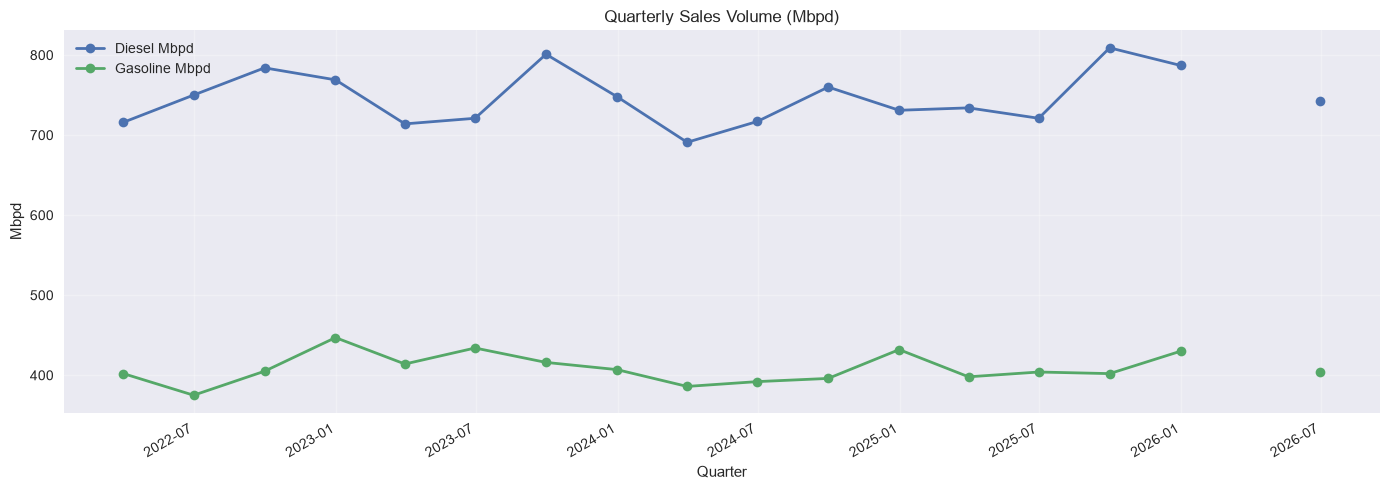

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['quarter_end'], df['diesel_mbpd'], marker='o', linewidth=2, label='Diesel Mbpd')
ax.plot(df['quarter_end'], df['gasoline_mbpd'], marker='o', linewidth=2, label='Gasoline Mbpd')
ax.set_title('Quarterly Sales Volume (Mbpd)')
ax.set_xlabel('Quarter')
ax.set_ylabel('Mbpd')
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

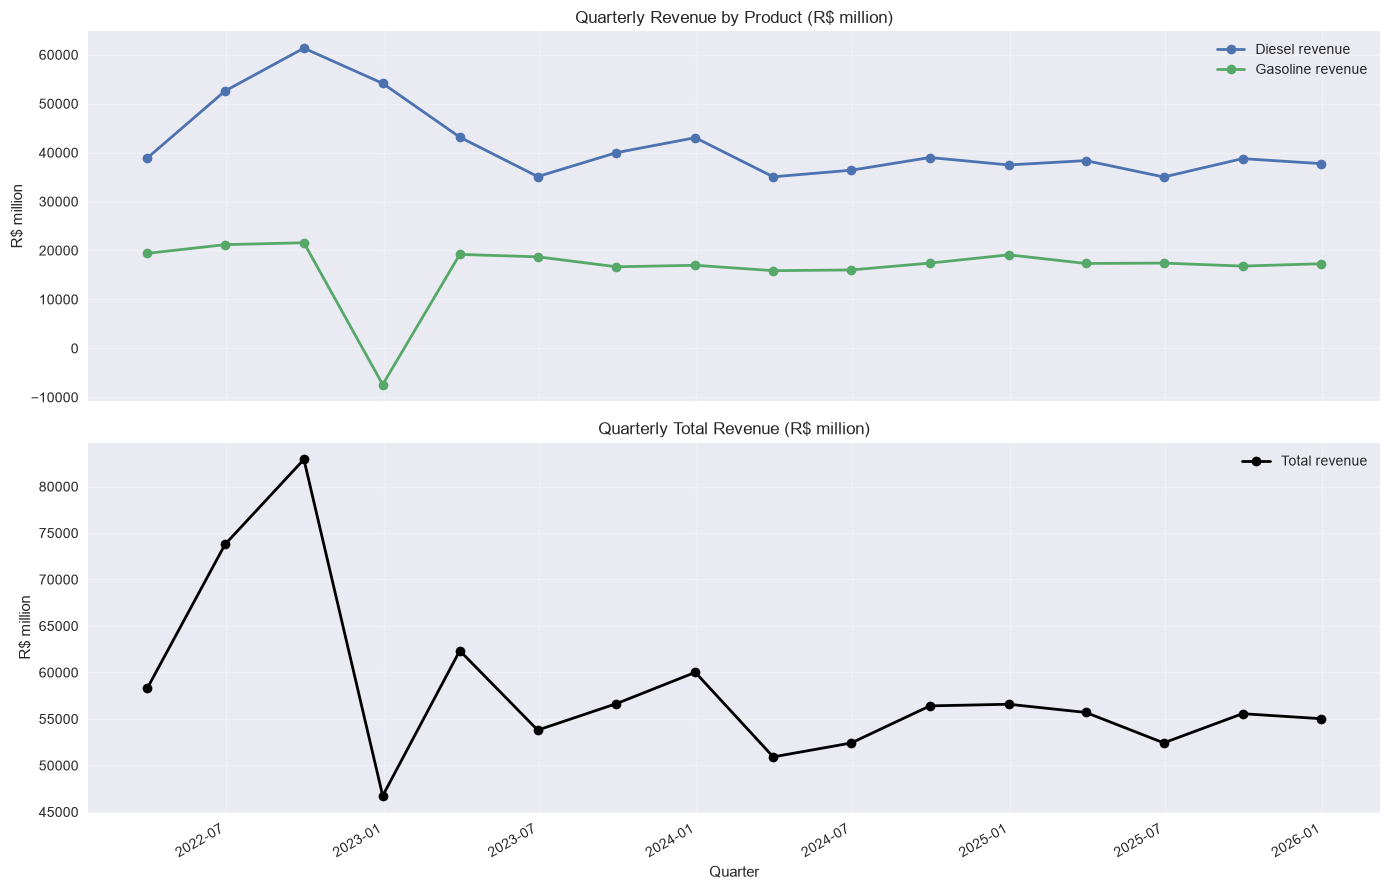

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df['quarter_end'], df['diesel_revenue_rsmn'], marker='o', linewidth=2, label='Diesel revenue')
axes[0].plot(df['quarter_end'], df['gasoline_revenue_rsmn'], marker='o', linewidth=2, label='Gasoline revenue')
axes[0].set_title('Quarterly Revenue by Product (R$ million)')
axes[0].set_ylabel('R$ million')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df['quarter_end'], df['total_revenue_rsmn'], marker='o', linewidth=2, color='black', label='Total revenue')
axes[1].set_title('Quarterly Total Revenue (R$ million)')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('R$ million')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

,quarter,diesel_share_pct,gasoline_share_pct,diesel_rev_per_mbpd,gasoline_rev_per_mbpd,diesel_revenue_rsmn_qoq_pct,gasoline_revenue_rsmn_qoq_pct,total_revenue_rsmn_qoq_pct
64,1Q22,66.705,33.295,54.295,48.269,NaN,NaN,NaN
65,2Q22,71.287,28.713,70.137,56.499,35.313,9.189,26.615
66,3Q22,73.980,26.020,78.244,53.272,16.615,1.831,12.370
67,4Q22,115.843,-15.843,70.402,-16.564,-11.744,-134.317,-43.637
68,1Q23,69.218,30.782,60.434,46.350,-20.298,-359.171,33.388
69,2Q23,65.241,34.759,48.681,43.088,-18.658,-2.548,-13.699
70,3Q23,70.590,29.410,49.923,40.048,13.929,-10.909,5.296
71,4Q23,71.722,28.278,57.543,41.695,7.637,1.861,5.938
72,1Q24,68.837,31.163,50.725,41.109,-18.566,-6.494,-15.152
73,2Q24,69.443,30.557,50.762,40.855,3.837,0.926,2.930


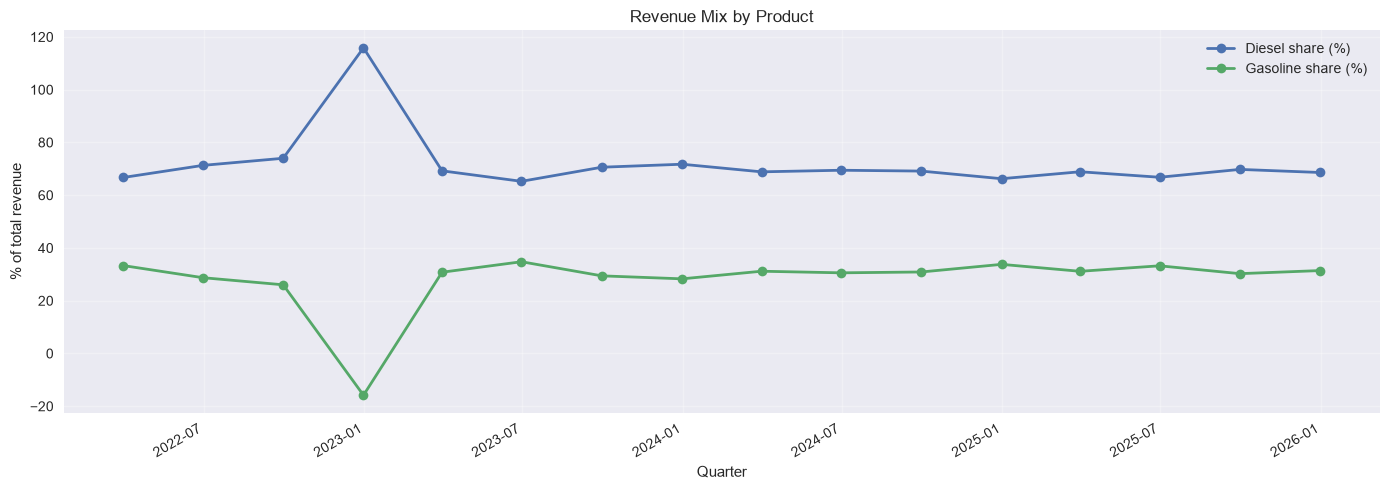

In [14]:
eda = df.copy()
eda['diesel_share_pct'] = 100 * eda['diesel_revenue_rsmn'] / eda['total_revenue_rsmn']
eda['gasoline_share_pct'] = 100 * eda['gasoline_revenue_rsmn'] / eda['total_revenue_rsmn']
eda['diesel_rev_per_mbpd'] = eda['diesel_revenue_rsmn'] / eda['diesel_mbpd']
eda['gasoline_rev_per_mbpd'] = eda['gasoline_revenue_rsmn'] / eda['gasoline_mbpd']

for col in ['diesel_mbpd', 'gasoline_mbpd', 'diesel_revenue_rsmn', 'gasoline_revenue_rsmn', 'total_revenue_rsmn']:
    eda[f'{col}_qoq_pct'] = 100 * eda[col].pct_change()

display(eda[[
    'quarter',
    'diesel_share_pct',
    'gasoline_share_pct',
    'diesel_rev_per_mbpd',
    'gasoline_rev_per_mbpd',
    'diesel_revenue_rsmn_qoq_pct',
    'gasoline_revenue_rsmn_qoq_pct',
    'total_revenue_rsmn_qoq_pct',
]].round(3))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(eda['quarter_end'], eda['diesel_share_pct'], marker='o', linewidth=2, label='Diesel share (%)')
ax.plot(eda['quarter_end'], eda['gasoline_share_pct'], marker='o', linewidth=2, label='Gasoline share (%)')
ax.set_title('Revenue Mix by Product')
ax.set_xlabel('Quarter')
ax.set_ylabel('% of total revenue')
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

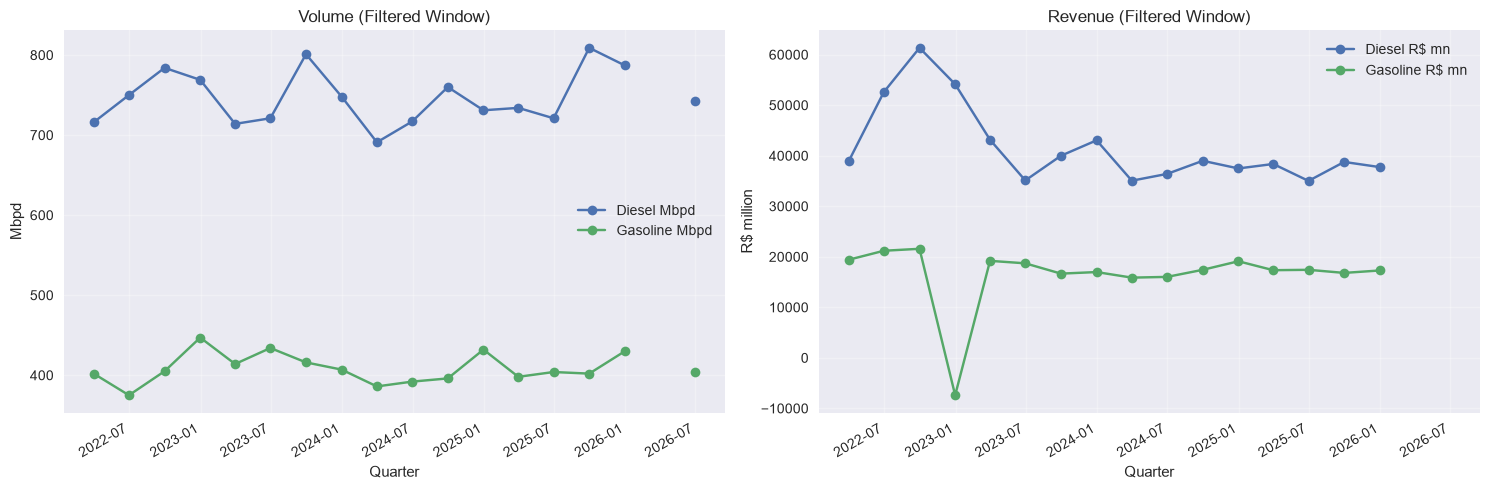

In [15]:
# Filtered window (use None for full range)
start_quarter = None  # e.g., '2024Q1'
end_quarter = None    # e.g., '2025Q4'

window = eda.copy()
if start_quarter is not None:
    window = window[window['quarter_period'] >= pd.Period(start_quarter, freq='Q')]
if end_quarter is not None:
    window = window[window['quarter_period'] <= pd.Period(end_quarter, freq='Q')]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
axes[0].plot(window['quarter_end'], window['diesel_mbpd'], marker='o', label='Diesel Mbpd')
axes[0].plot(window['quarter_end'], window['gasoline_mbpd'], marker='o', label='Gasoline Mbpd')
axes[0].set_title('Volume (Filtered Window)')
axes[0].set_ylabel('Mbpd')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(window['quarter_end'], window['diesel_revenue_rsmn'], marker='o', label='Diesel R$ mn')
axes[1].plot(window['quarter_end'], window['gasoline_revenue_rsmn'], marker='o', label='Gasoline R$ mn')
axes[1].set_title('Revenue (Filtered Window)')
axes[1].set_ylabel('R$ million')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

for ax in axes:
    ax.set_xlabel('Quarter')

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## Margem bruta do segmento RT&M

Fonte: ITR da Petrobras, **nota 8 — Informações por segmento de negócio** (`Refining, Transportation & Marketing`). Valores em R$ milhões. Margem % = lucro bruto / receita de vendas do segmento.

A margem bruta de diesel e gasolina por produto não é divulgada. O CPV sai por natureza, não por produto.

**Se 2022–2023 aparecer NaN:** esses trimestres são anteriores à divulgação da linha de produto no RT&M. O snapshot não inventa esses valores.


RT&M sem margem nestes trimestres (o snapshot não preenche): ['1Q26', '2Q26']


,quarter,quarter_end,rtm_sales_revenue_rsmn,rtm_gross_profit_rsmn,rtm_gross_margin_pct,extraction_note
64,1Q22,2022-03-31,128476.0,16311.0,12.696,
65,2Q22,2022-06-30,157429.0,25532.0,16.218,
66,3Q22,2022-09-30,154035.0,14428.0,9.367,
67,4Q22,2022-12-31,144757.0,17493.0,12.084,Q4 revenue derived as FY minus Jan-Sep; Q4 RT&...
68,1Q23,2023-03-31,129052.0,15449.0,11.971,
69,2Q23,2023-06-30,104328.0,8619.0,8.261,
70,3Q23,2023-09-30,115750.0,11235.0,9.706,
71,4Q23,2023-12-31,125208.0,10777.0,8.607,Q4 revenue derived as FY minus Jan-Sep; Q4 RT&...
72,1Q24,2024-03-31,109905.0,10934.0,9.949,
73,2Q24,2024-06-30,114935.0,7825.0,6.808,


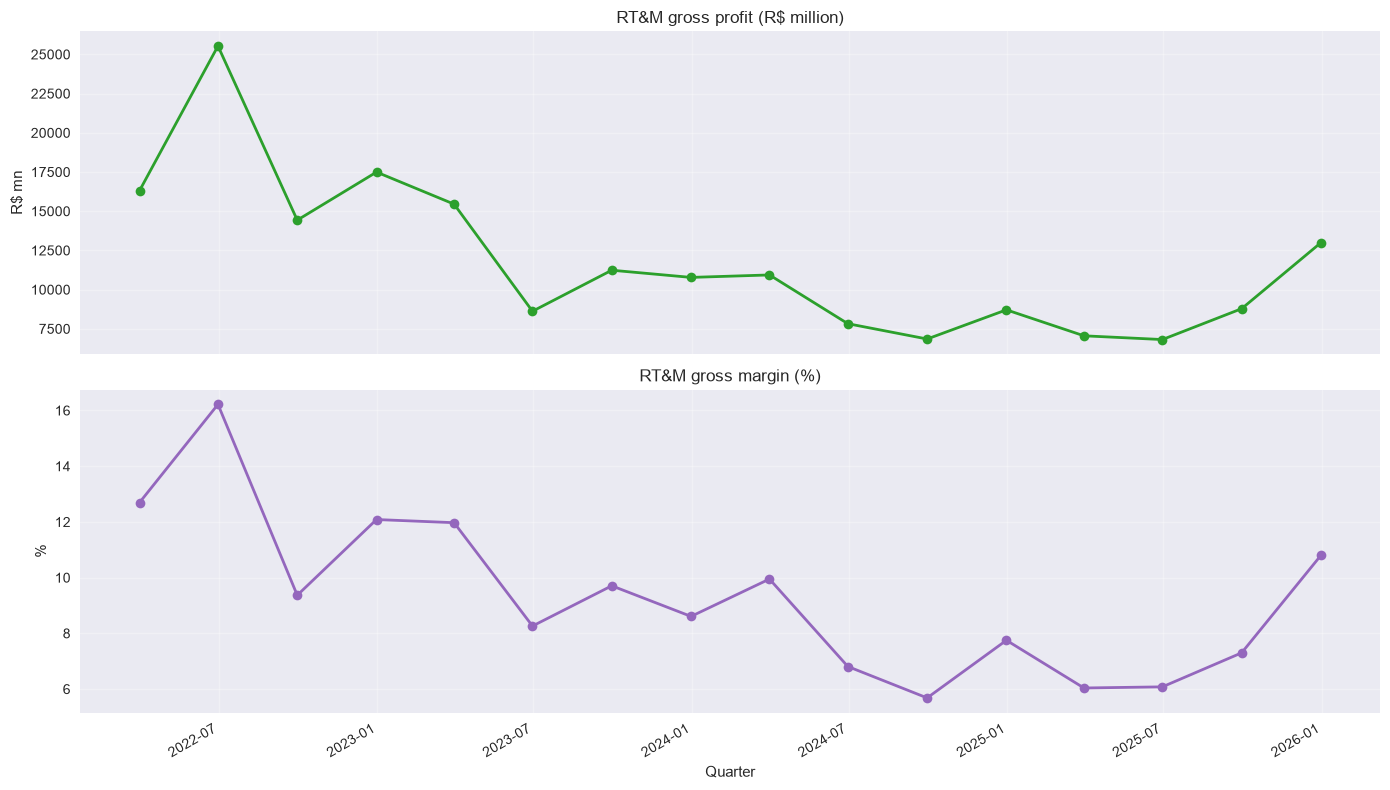

In [17]:
# PPI modeling window (df already truncated to PPI anchor in load cell).
rtm_window = df.copy()
missing = rtm_window.loc[rtm_window['rtm_gross_margin_pct'].isna(), 'quarter'].tolist()
if missing:
    print(
        'RT&M sem margem nestes trimestres (o snapshot não preenche): '
        f'{missing}'
    )

rtm = rtm_window[
    ['quarter', 'quarter_end', 'rtm_sales_revenue_rsmn', 'rtm_gross_profit_rsmn', 'rtm_gross_margin_pct', 'extraction_note']
].copy()
display(
    rtm.round({
        'rtm_sales_revenue_rsmn': 3,
        'rtm_gross_profit_rsmn': 3,
        'rtm_gross_margin_pct': 3,
    })
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(rtm['quarter_end'], rtm['rtm_gross_profit_rsmn'], marker='o', linewidth=2, color='tab:green')
axes[0].set_title('RT&M gross profit (R$ million)')
axes[0].set_ylabel('R$ mn')
axes[0].grid(True, alpha=0.3)

axes[1].plot(rtm['quarter_end'], rtm['rtm_gross_margin_pct'], marker='o', linewidth=2, color='tab:purple')
axes[1].set_title('RT&M gross margin (%)')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('%')
axes[1].grid(True, alpha=0.3)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()
